<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.3836 acc 0.626 | val loss 0.8744 acc 0.663 *


[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.2753 acc 0.686 | val loss 0.9143 acc 0.622


[InceptionNet v3] Epoch   3/100 | LR: 2.85e-04 | train loss 1.2438 acc 0.687 | val loss 0.5864 acc 0.783 *


[InceptionNet v3] Epoch   4/100 | LR: 2.85e-04 | train loss 1.1848 acc 0.711 | val loss 0.6140 acc 0.786


[InceptionNet v3] Epoch   5/100 | LR: 2.85e-04 | train loss 1.1372 acc 0.703 | val loss 0.6536 acc 0.765


...

[InceptionNet v3] Epoch  46/100 | LR: 2.85e-05 | train loss 0.2684 acc 0.926 | val loss 0.4481 acc 0.842


[InceptionNet v3] Epoch  47/100 | LR: 2.85e-05 | train loss 0.2921 acc 0.925 | val loss 0.4908 acc 0.836


[InceptionNet v3] Epoch  48/100 | LR: 2.85e-05 | train loss 0.2792 acc 0.927 | val loss 0.4909 acc 0.827


[InceptionNet v3] Epoch  49/100 | LR: 2.85e-05 | train loss 0.2553 acc 0.935 | val loss 0.4838 acc 0.842


[InceptionNet v3] Epoch  50/100 | LR: 2.85e-05 | train loss 0.2456 acc 0.934 | val loss 0.5165 acc 0.821

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 50.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4264)


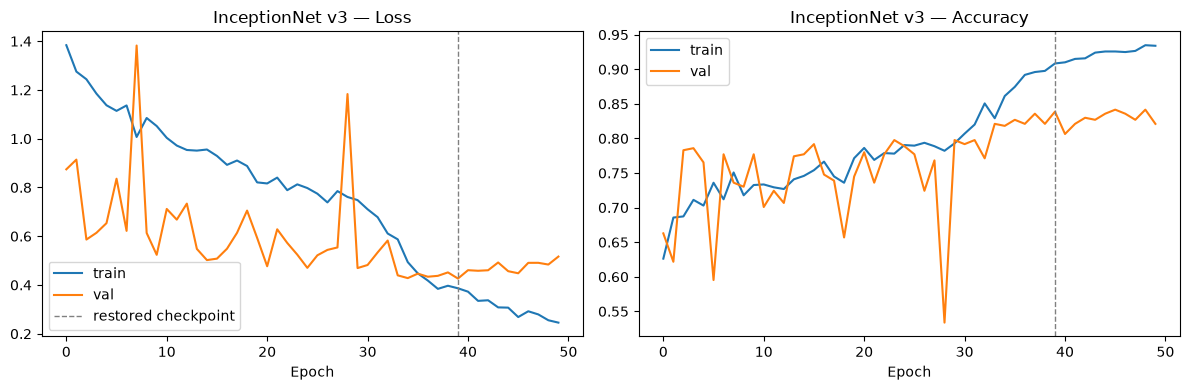

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.784


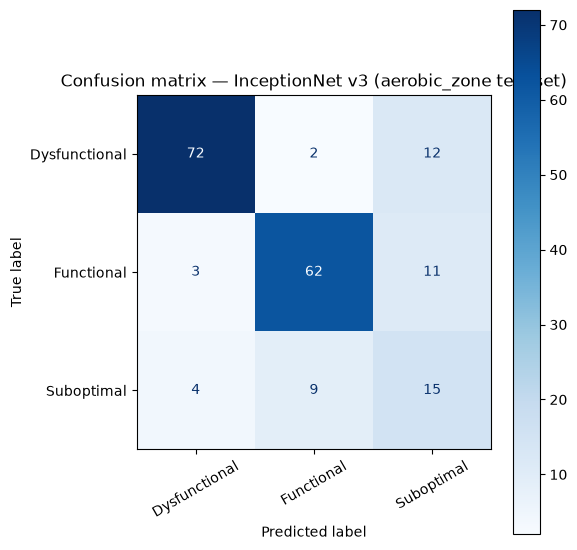

               precision    recall  f1-score   support

Dysfunctional      0.911     0.837     0.873        86
   Functional      0.849     0.816     0.832        76
   Suboptimal      0.395     0.536     0.455        28

     accuracy                          0.784       190
    macro avg      0.718     0.730     0.720       190
 weighted avg      0.810     0.784     0.795       190



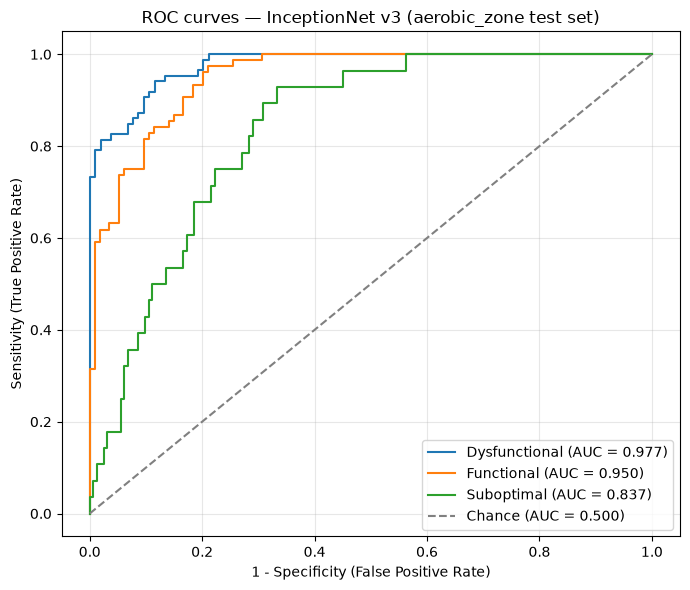

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.977
  Functional     : 0.950
  Suboptimal     : 0.837

Mean AUC (over 3/3 classes with test examples): 0.921


(np.float64(0.7842105263157895),
 {'Dysfunctional': 0.9768559928443649,
  'Functional': 0.9503693444136656,
  'Suboptimal': 0.8370811287477955})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_inception_v3_stratified.pkl
Saved model weights to ../models/aerobic_zone_inception_v3_cnn.pt
